<a href="https://colab.research.google.com/github/erknoztk/capstone/blob/master/cp2.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [147]:
df = pd.read_csv("cp2/DAYTON_hourly.csv")
df.head()

,Datetime,DAYTON_MW
0,2004-12-31 01:00:00,1596.0
1,2004-12-31 02:00:00,1517.0
2,2004-12-31 03:00:00,1486.0
3,2004-12-31 04:00:00,1469.0
4,2004-12-31 05:00:00,1472.0


In [148]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121275 entries, 0 to 121274
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Datetime   121275 non-null  object 
 1   DAYTON_MW  121275 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


,DAYTON_MW
count,121275.000000
mean,2037.851140
std,393.403153
min,982.000000
25%,1749.000000
50%,2009.000000
75%,2279.000000
max,3746.000000


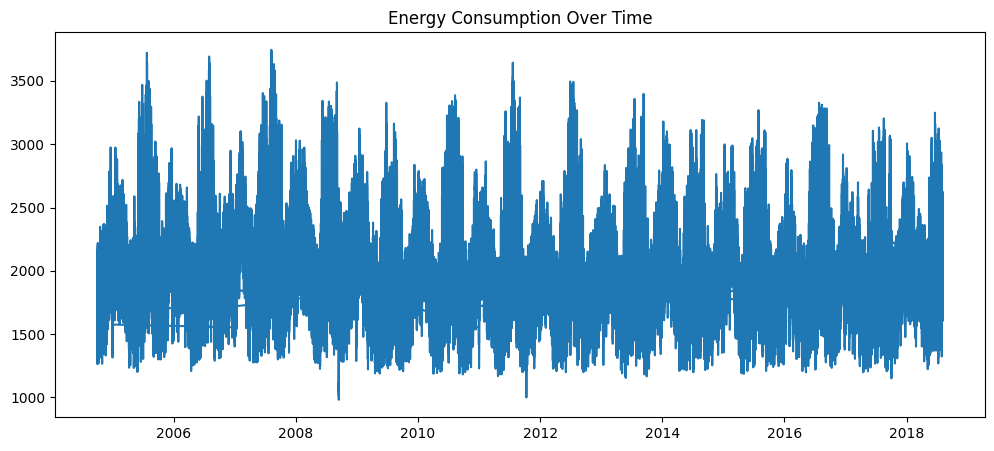

In [149]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.set_index("Datetime", inplace=True)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["DAYTON_MW"])
plt.title("Energy Consumption Over Time")
plt.show()

In [150]:
mean_val = df["DAYTON_MW"].mean()
std_val = df["DAYTON_MW"].std()

lower_bound = mean_val - 3 * std_val
upper_bound = mean_val + 3 * std_val

df["anomaly"] = (df["DAYTON_MW"] < lower_bound) | (df["DAYTON_MW"] > upper_bound)

In [151]:
df_feat = df.copy()

df_feat["hour"] = df_feat.index.hour
df_feat["day"] = df_feat.index.day
df_feat["month"] = df_feat.index.month
df_feat["dayofweek"] = df_feat.index.dayofweek

In [152]:
df_feat["roll_mean_24"] = df_feat["DAYTON_MW"].rolling(window=24, min_periods=1).mean()
df_feat["roll_std_24"] = df_feat["DAYTON_MW"].rolling(window=24, min_periods=1).std()

In [153]:
df_feat["diff_1"] = df_feat["DAYTON_MW"].diff().fillna(0)

In [154]:
df_feat["change_ratio"] = df_feat["DAYTON_MW"] / (df_feat["roll_mean_24"] + 1e-6)

In [155]:
feature_cols = [
    "DAYTON_MW",
    "hour",
    "day",
    "month",
    "dayofweek",
    "roll_mean_24",
    "roll_std_24",
    "diff_1",
    "change_ratio"
]

X = df_feat[feature_cols]

In [156]:
df_feat[feature_cols].head()

,DAYTON_MW,hour,day,month,dayofweek,roll_mean_24,roll_std_24,diff_1,change_ratio
Datetime,,,,,,,,,
2004-12-31 01:00:00,1596.0,1,31,12,4,1596.0,NaN,0.0,1.000000
2004-12-31 02:00:00,1517.0,2,31,12,4,1556.5,55.861436,-79.0,0.974623
2004-12-31 03:00:00,1486.0,3,31,12,4,1533.0,56.718604,-31.0,0.969341
2004-12-31 04:00:00,1469.0,4,31,12,4,1517.0,56.290911,-17.0,0.968359
2004-12-31 05:00:00,1472.0,5,31,12,4,1508.0,52.739928,3.0,0.976127


In [157]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [158]:
from sklearn.ensemble import IsolationForest

# Model tanımı
iso = IsolationForest(
    n_estimators=300,
    contamination=0.02,  # veride %2 anomali varsayımı
    random_state=42
)

# Modeli eğitme
iso.fit(X_scaled)

# Tahmin (1 = normal, -1 = anomaly)
pred_iso = iso.predict(X_scaled)

# Anomaly label dönüşümü (1 = anomaly, 0 = normal)
df_feat["anomaly_iso"] = (pred_iso == -1).astype(int)

# Sonuç kontrol
df_feat[["anomaly_iso"]].head()

,anomaly_iso
Datetime,
2004-12-31 01:00:00,0
2004-12-31 02:00:00,0
2004-12-31 03:00:00,0
2004-12-31 04:00:00,0
2004-12-31 05:00:00,0


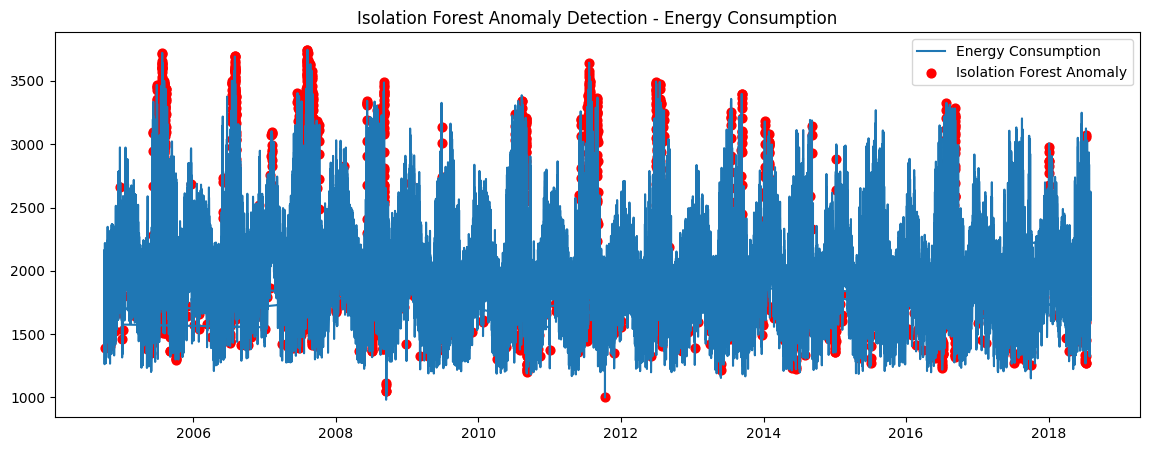

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# normal enerji tüketimi
plt.plot(df_feat.index, df_feat["DAYTON_MW"], label="Energy Consumption")

# anomaly noktaları
anom_points = df_feat[df_feat["anomaly_iso"] == 1]

plt.scatter(
    anom_points.index,
    anom_points["DAYTON_MW"],
    color="red",
    s=40,
    label="Isolation Forest Anomaly"
)

plt.title("Isolation Forest Anomaly Detection - Energy Consumption")
plt.legend()
plt.show()

In [160]:
df_feat["anomaly"].value_counts()

,count
anomaly,
False,120576
True,699


In [161]:
normal_df = df_feat[df_feat["anomaly"] == 1]

In [162]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = normal_df[["DAYTON_MW"]]
X_train_scaled = scaler.fit_transform(X_train)